In [1]:
#-------------------------- import packages --------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#-------------------------- generate data features --------------------------
np.random.seed(0)
num_vars = 10 # number of variables to generate
num_samples = 50_000 # number of observations
cat_vars = {} # name and number of categories
variables = {}
for i in range(1, num_vars + 1):
    
    # continuous variables
    if f"X{i}" not in cat_vars.keys():
        variables[f'X{i}'] = np.random.uniform(-1, 1, num_samples)
    
    # categorical variables
    else:
        variables[f'X{i}'] = np.random.randint(0, cat_vars[f"X{i}"], num_samples)

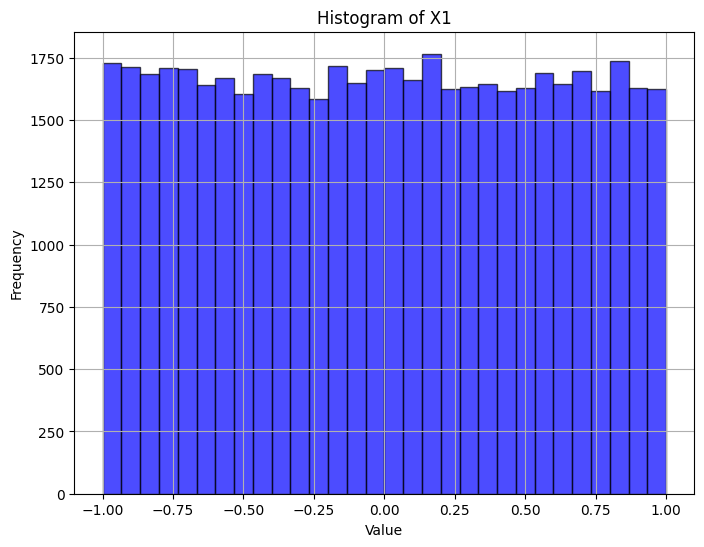

In [3]:
#-------------------------- check numeric --------------------------
plt.figure(figsize = (8, 6))
plt.hist(variables["X1"], bins = 30, color = 'blue', alpha = 0.7, edgecolor = 'black')
plt.title('Histogram of X1')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [4]:
#-------------------------- define functions to calculate main and pairwise interaction effect --------------------------

# main effect
def main_effect(var_name, var_values):
    if var_name == "X1":
        return np.abs(var_values) * np.sin(8 * var_values)
    elif var_name == "X2":
        return 1/2*np.sin(8*var_values)**3 - np.cos(4*var_values)/4 + (var_values**2)/4

# pairwise interaction
def interaction_effect(var_name, var1, var2):
    if var_name == "f34":
        return -(var1 + 0.5) * np.exp(-var2)
    elif var_name == "f56":
        return 1.5 * np.sin(2 * np.pi * (var1 - 0.5) * (var2 + 0.5))
    elif var_name == "f78":
        return np.sign(50*(np.sin(10*var1) + 0.5))*np.sign(50*(np.sin(10*var2) - 0.5))

### Main Effects:

<!-- 1. $ f_1(X_1) $:
$$
f_1(X_1) = \frac{1}{4}\frac{e^{-4X_1}}{1 + 16X_1^2}
$$ -->

1. $ f_1(X_1) $:
$$
f_1(X_1) = |X_1| \sin(8X_1)
$$

2. $ f_2(X_2) $:
$$
f_2(X_2) = \frac{1}{2}\sin^3(8X_2) - \frac{\cos(4X_2)}{4} + \frac{X_2^2}{4}
$$

### Pairwise Interaction Effects:

1. $ f_{34}(X_3, X_4) $:
$$
f_{34}(X_3, X_4) = -(X_3 + 0.5)e^{-X_4}
$$

2. $ f_{56}(X_5, X_6) $:
$$
f_{56}(X_5, X_6) = 1.5\sin(2\pi (X_5 - 0.5)(X_6 + 0.5))
$$

3. $ f_{78}(X_7, X_8) $:
$$
f_{78}(X_7, X_8) = \text{sign}\left( 50 \left( \sin\left(10X_7\right) + 0.5 \right) \right) \times \text{sign}\left( 50 \left( \sin\left(10X_8\right) - 0.5 \right) \right)
$$

In [5]:
#-------------------------- generate mean response --------------------------
effect = {}

# Main effects
for i in range(1, 3):
    effect[f"f{i}"] = main_effect(f"X{i}", variables[f"X{i}"])

# Interaction effects
effect["f34"] = interaction_effect("f34", variables["X3"], variables["X4"])
effect["f56"] = interaction_effect("f56", variables["X5"], variables["X6"])
effect["f78"] = interaction_effect("f78", variables["X7"], variables["X8"])

# Calculate mu - the log of the mean response
mu = 6 + sum(effect.values())

Text(0.5, 1.0, 'Distribution of Log(E(Y|X))')

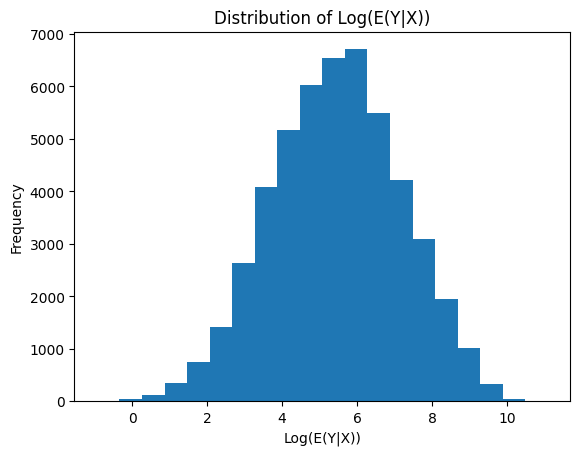

In [6]:
#-------------------------- mean response distribution --------------------------
plt.hist(mu, bins = 20)
plt.xlabel("Log(E(Y|X))")
plt.ylabel("Frequency")
plt.title("Distribution of Log(E(Y|X))")

In [7]:
#-------------------------- check min/mean/max of mu --------------------------
print(f"Min of mu: {np.min(mu)}")
print(f"Mean of mu: {np.mean(mu)}")
print(f"Max of mu: {np.max(mu)}")

Min of mu: -0.935648784333762
Mean of mu: 5.4562311463664965
Max of mu: 11.08385754125943


In [8]:
#-------------------------- check min/mean/max of exp(mu) --------------------------
print(f"Min of exp(mu): {np.exp(np.min(mu))}")
print(f"Mean of exp(mu): {np.exp(np.mean(mu))}")
print(f"Max of exp(mu): {np.exp(np.max(mu))}")

Min of exp(mu): 0.39233124457827917
Mean of exp(mu): 234.21304417976015
Max of exp(mu): 65111.57014843911


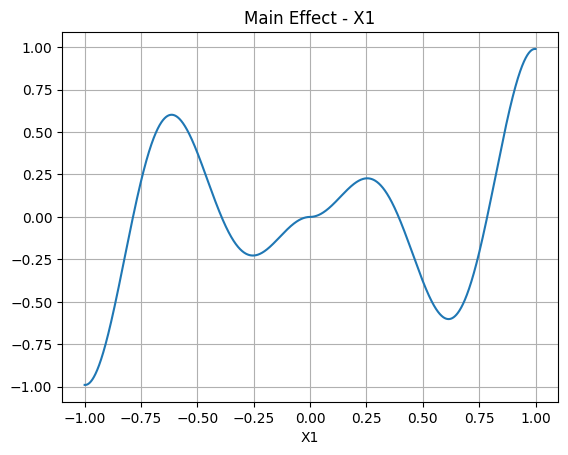

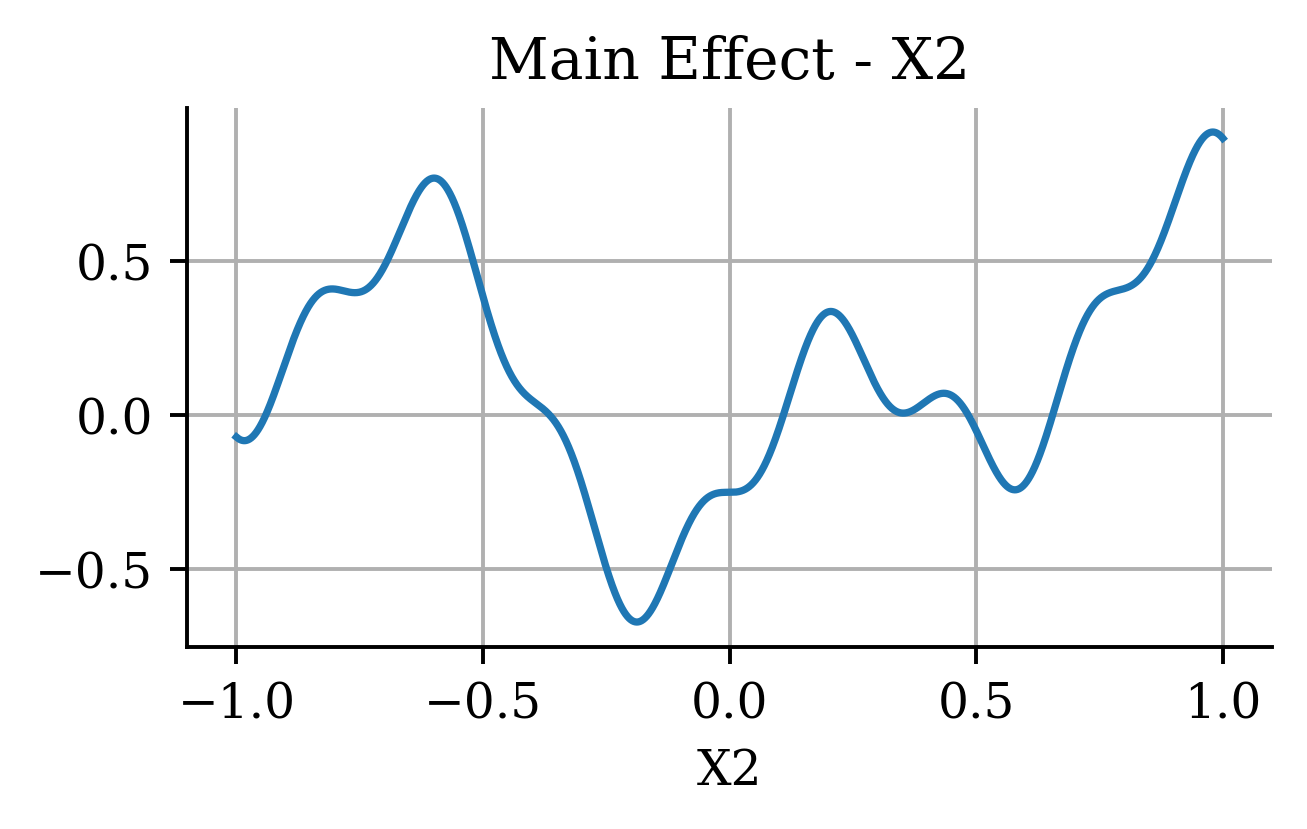

In [9]:
#-------------------------- plot functions for main effect --------------------------
for i in range(1,len(variables) + 1):
    
    if i in [1, 2]:
        var = f"X{i}"
        values = variables[var]  # get the values for the current variable
        
        # Calculate the main effect
        effect = main_effect(var, values)
        
        # # Create the plot
        # plt.figure(figsize=(12, 6))

        # If the variable is categorical, use line plot
        if var in cat_vars:
            unique_vals = np.unique(values)
            mean_effects = [np.mean(effect[values == val]) for val in unique_vals]
            plt.plot(unique_vals, mean_effects, marker='o', color='blue', label=f'Main Effect of {var}', linestyle='-')
        else:
            sns.lineplot(x = values, y = effect)
            # plt.scatter(values, effect, color='blue', label=f'Main Effect of {var}')
        
        # Add labels and title
        plt.xlabel(f'{var}')
        # plt.ylabel('Main Effect')
        plt.title(f'Main Effect - {var}')
        plt.grid(True)
        
        plt.rcParams["figure.figsize"] = (4.0, 2.0)
        plt.rcParams["figure.dpi"] = 350
        plt.rcParams["savefig.bbox"] = "tight"
        plt.rcParams["font.family"] = "serif"
        plt.rcParams["axes.spines.right"] = False
        plt.rcParams["axes.spines.top"] = False
        
        # Show the plot
        plt.show()

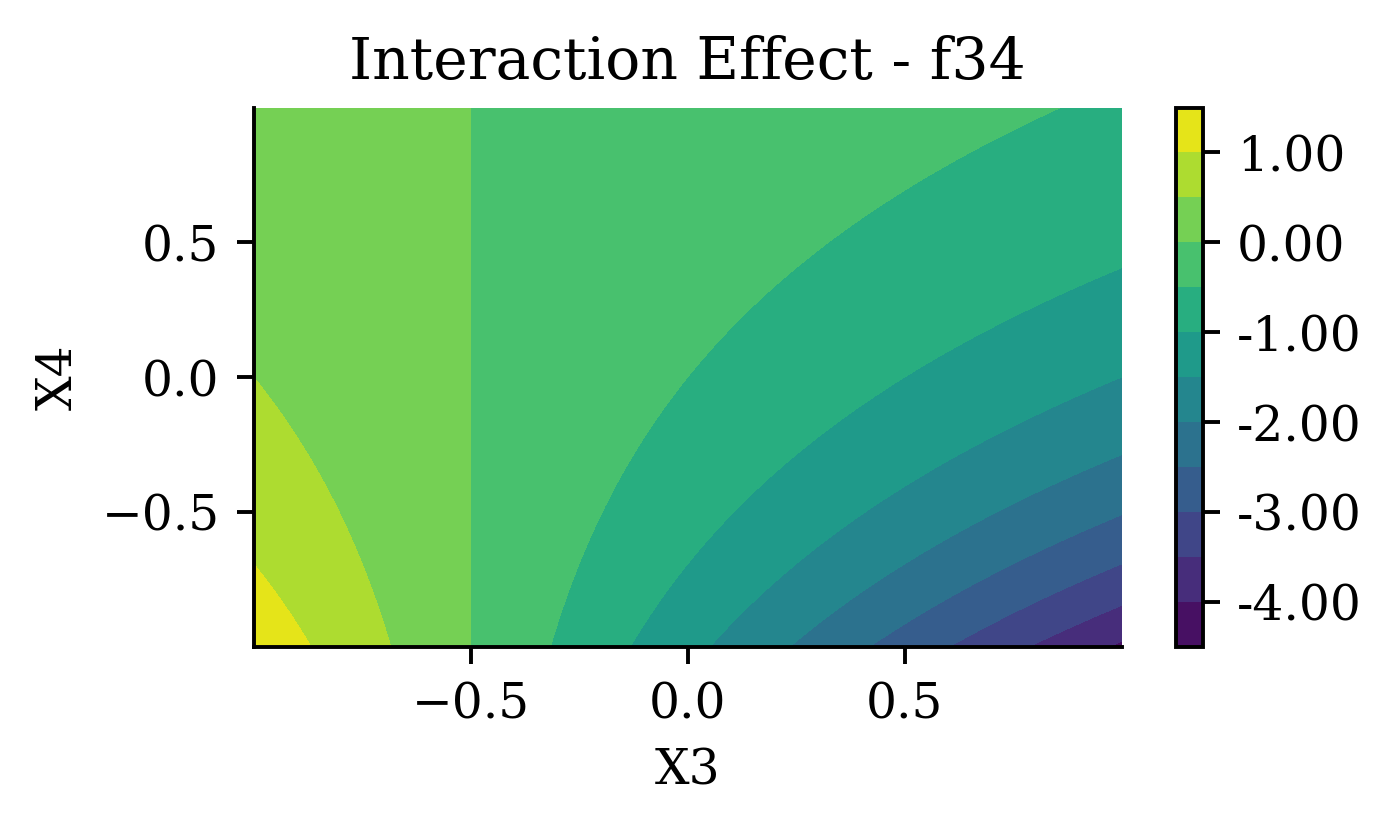

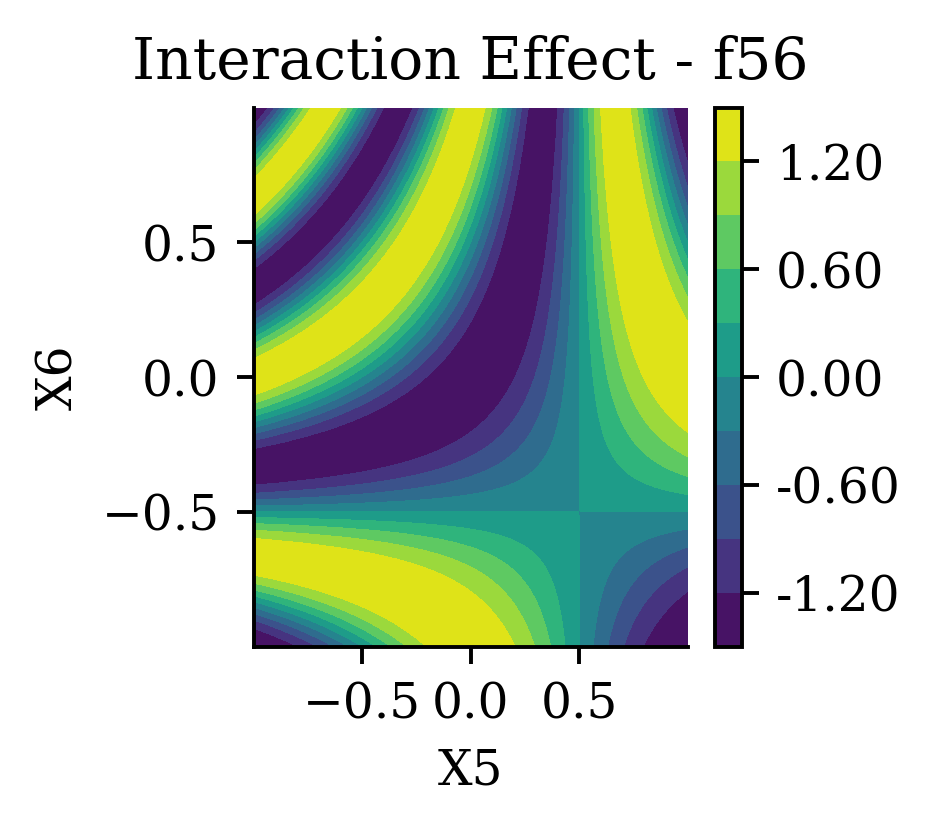

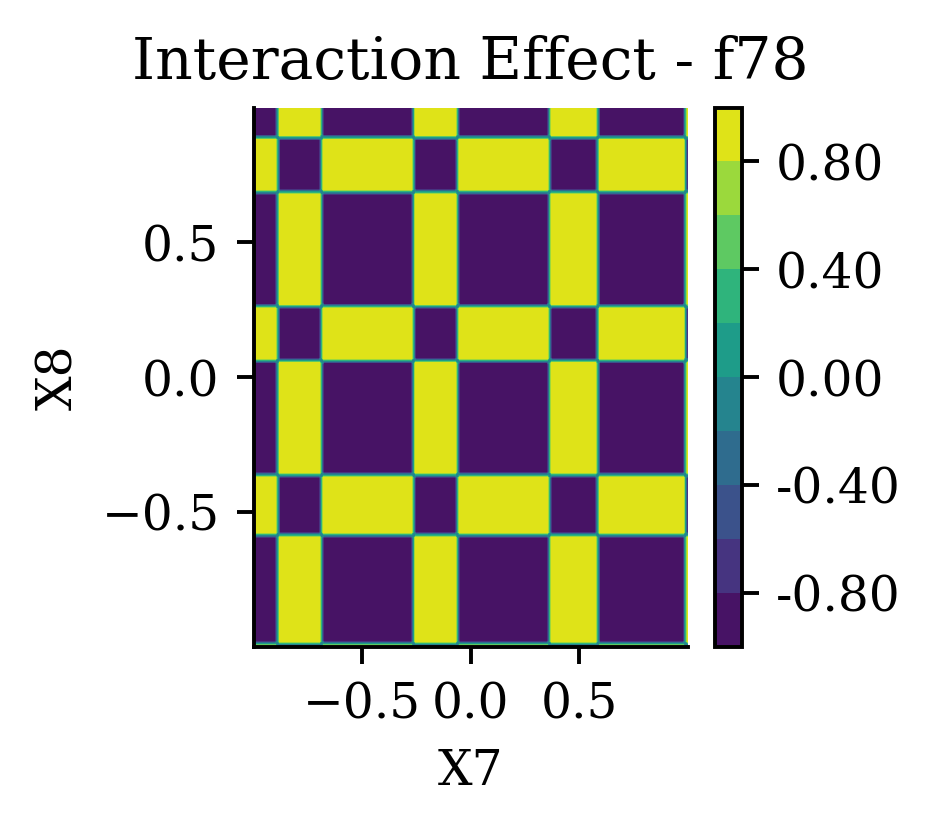

In [10]:
#-------------------------- plot the pairwise interaction effect --------------------------
# Interaction plots
interaction_pairs = {
    "f34": ("X3", "X4"),
    "f56": ("X5", "X6"),
    "f78": ("X7", "X8")
}

# Loop through each interaction effect and plot the heatmap
for interaction, (var1, var2) in interaction_pairs.items():
    x1 = variables[var1]
    x2 = variables[var2]

    # Create a meshgrid for plotting
    X1, X2 = np.meshgrid(np.linspace(x1.min(), x1.max(), 100), np.linspace(x2.min(), x2.max(), 100))
    
    # Calculate the interaction effect using the defined function
    if interaction == "f34":
        Y = - (X1 + 0.5) * np.exp(-X2)
    elif interaction == "f56":
        Y = 1.5 * np.sin(2 * np.pi * (X1 - 0.5) * (X2 + 0.5))
    elif interaction == "f78":
        Y = np.sign(50*(np.sin(10*X1) + 0.5))*np.sign(50*(np.sin(10*X2) - 0.5))

    # Create the heatmap
    # plt.figure(figsize = (8, 6))
    plt.contourf(X1, X2, Y, levels = 10, cmap = 'viridis')
    plt.colorbar(format="%.2f")
    plt.title(f'Interaction Effect - {interaction}')
    plt.xlabel(var1)
    plt.ylabel(var2)

    # aesthetic
    plt.rcParams["figure.figsize"] = (2, 2) # (for square figures)
    plt.rcParams["figure.dpi"] = 350
    plt.rcParams["savefig.bbox"] = "tight"
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.spines.top"] = False

    plt.show()

In [11]:
#-------------------------- generate target variables --------------------------
data = pd.DataFrame(variables)

'assume a Gamma distribution with mean = exp(mu)'
phi_low = 1 # dispersion for low variance distribution
phi_high = 5 # dispersion for low variance distribution

# for low variance
response_low = np.random.gamma(shape = 1/phi_low, scale = phi_low*np.exp(mu))
data_low = data.copy()
data_low["Y"] = response_low

# for high variance
response_high = np.random.gamma(shape = 1/phi_high, scale = phi_high*np.exp(mu))
data_high = data.copy()
data_high["Y"] = response_high

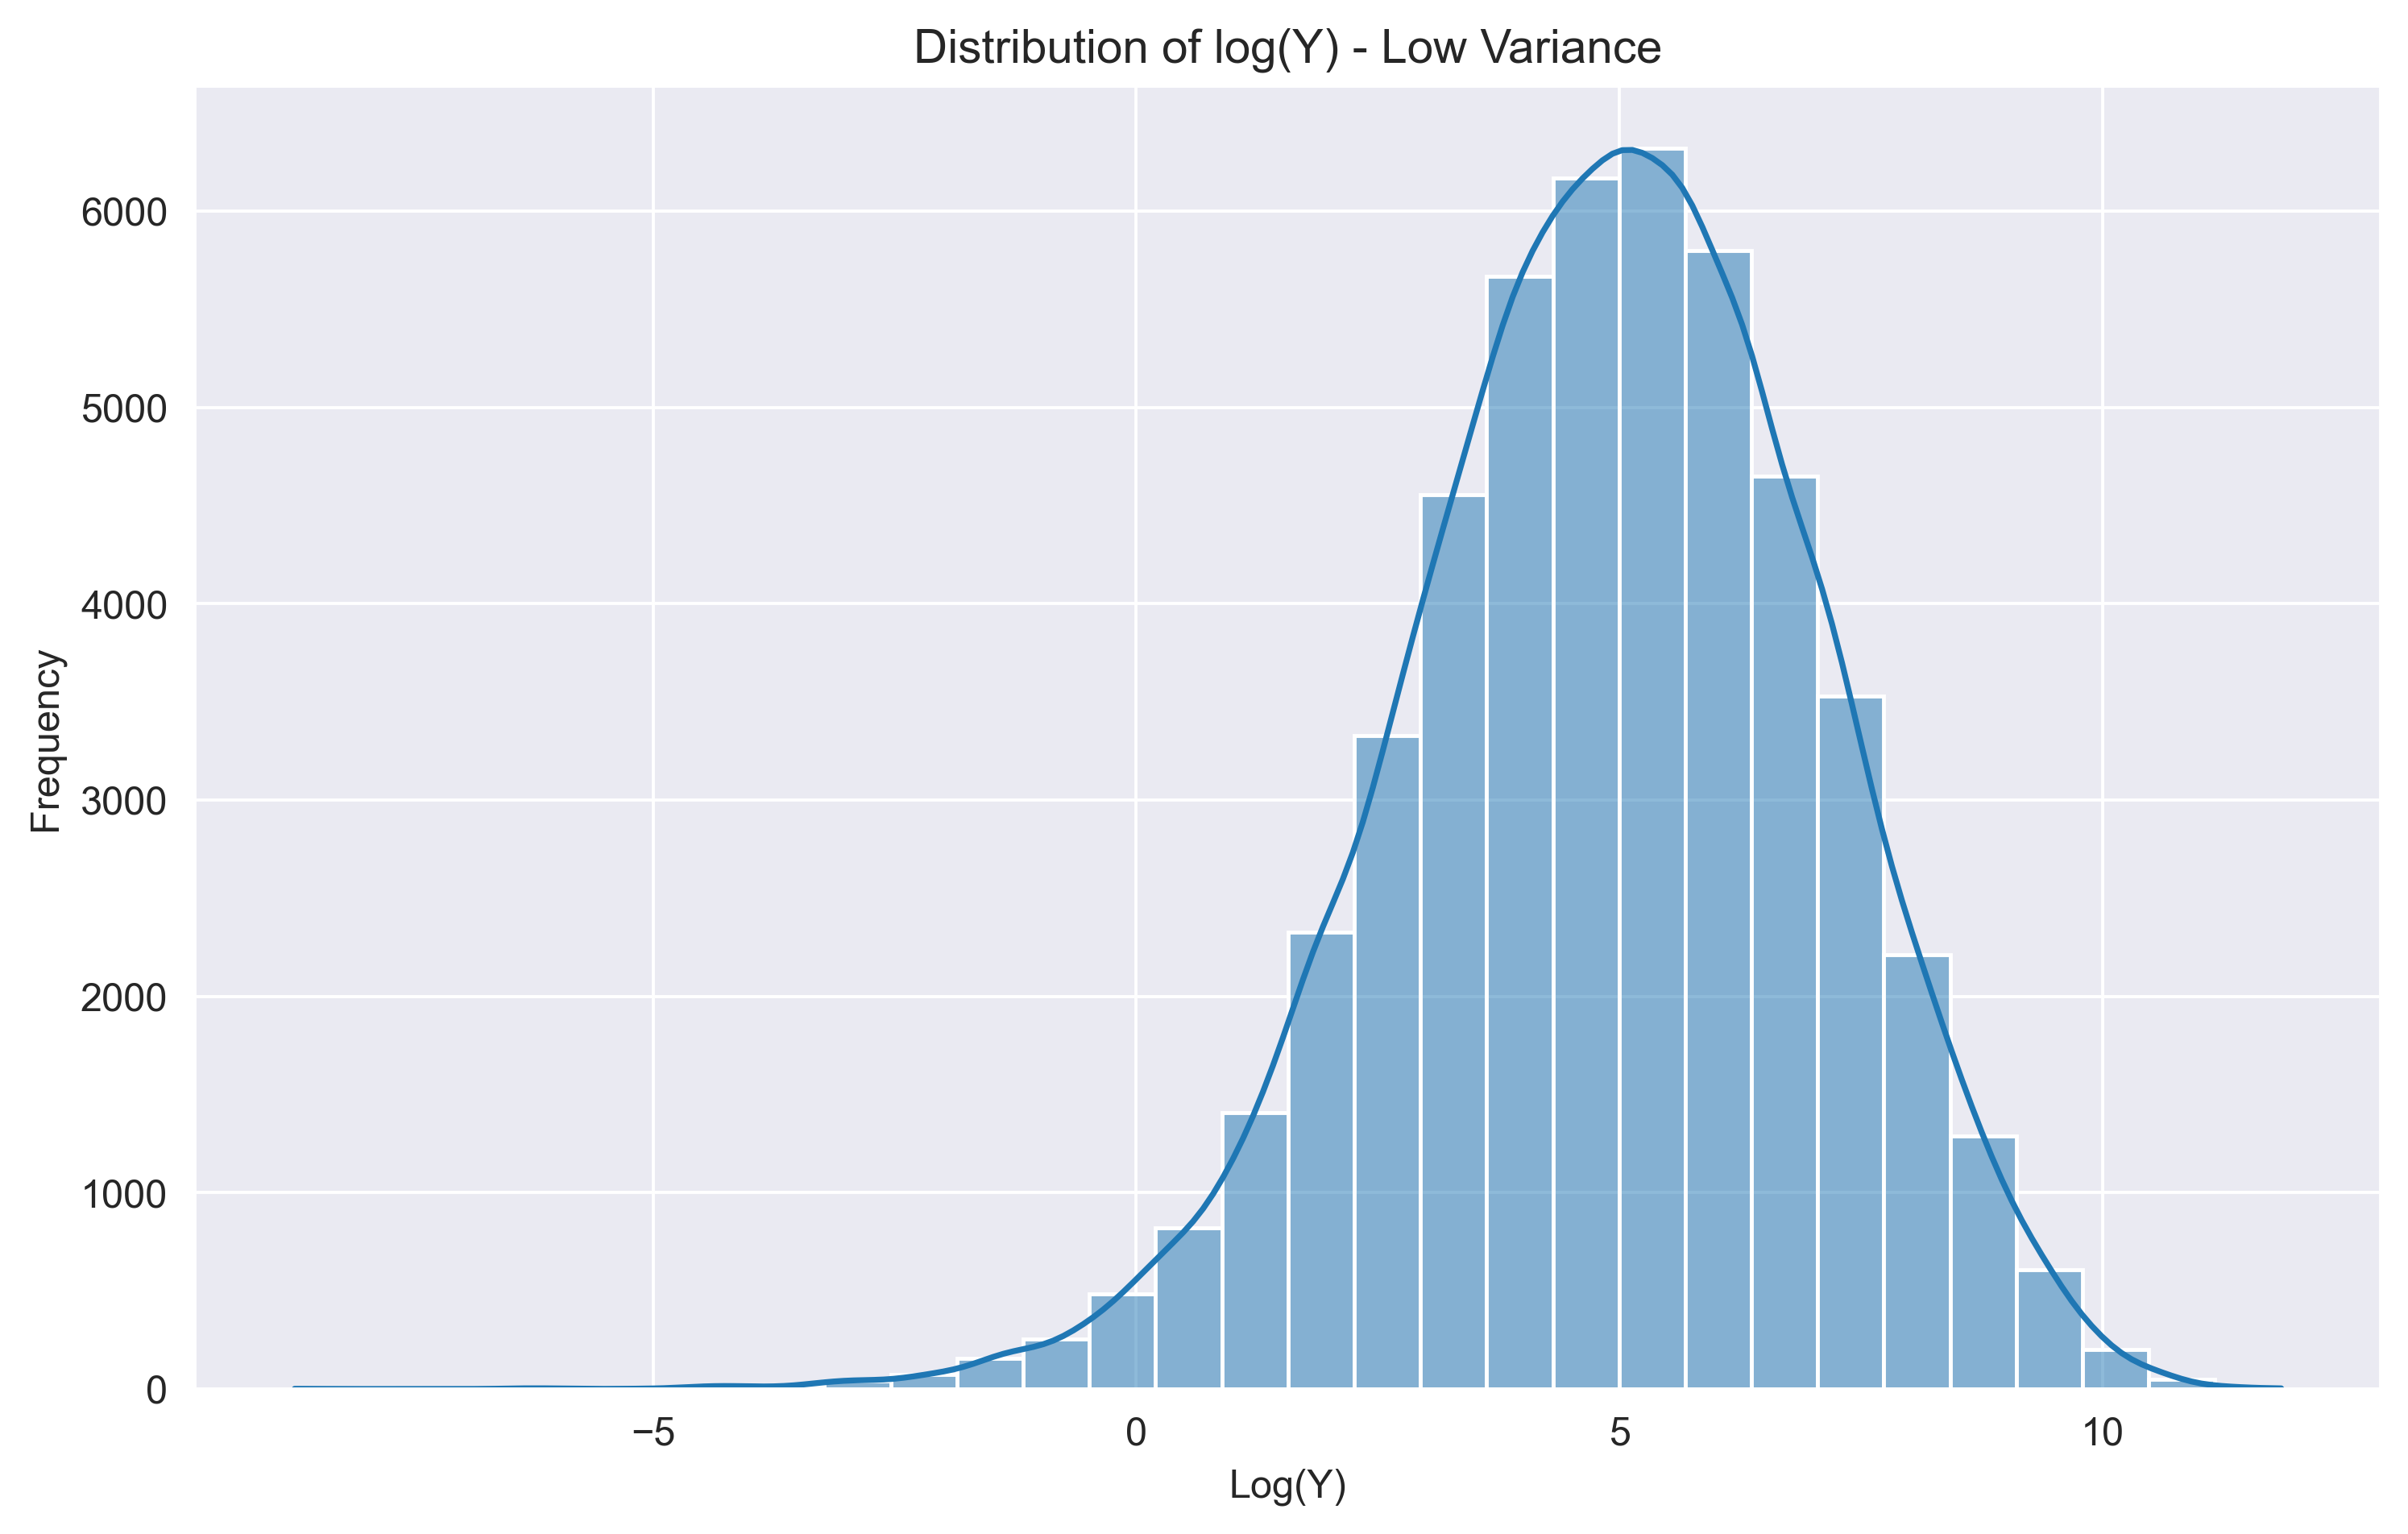

In [12]:
#-------------------------- distribution of log(response) - low variance --------------------------
plt.figure(figsize = (10, 6)) # set the size of the figure
sns.set_style("darkgrid")
sns.histplot(np.log(data_low['Y']), bins = 30, kde = True) # draw the chart
plt.title('Distribution of log(Y) - Low Variance')
plt.xlabel('Log(Y)')
plt.ylabel('Frequency')
plt.tick_params(axis = 'x')
plt.tick_params(axis = 'y')
plt.grid(True)
plt.show()

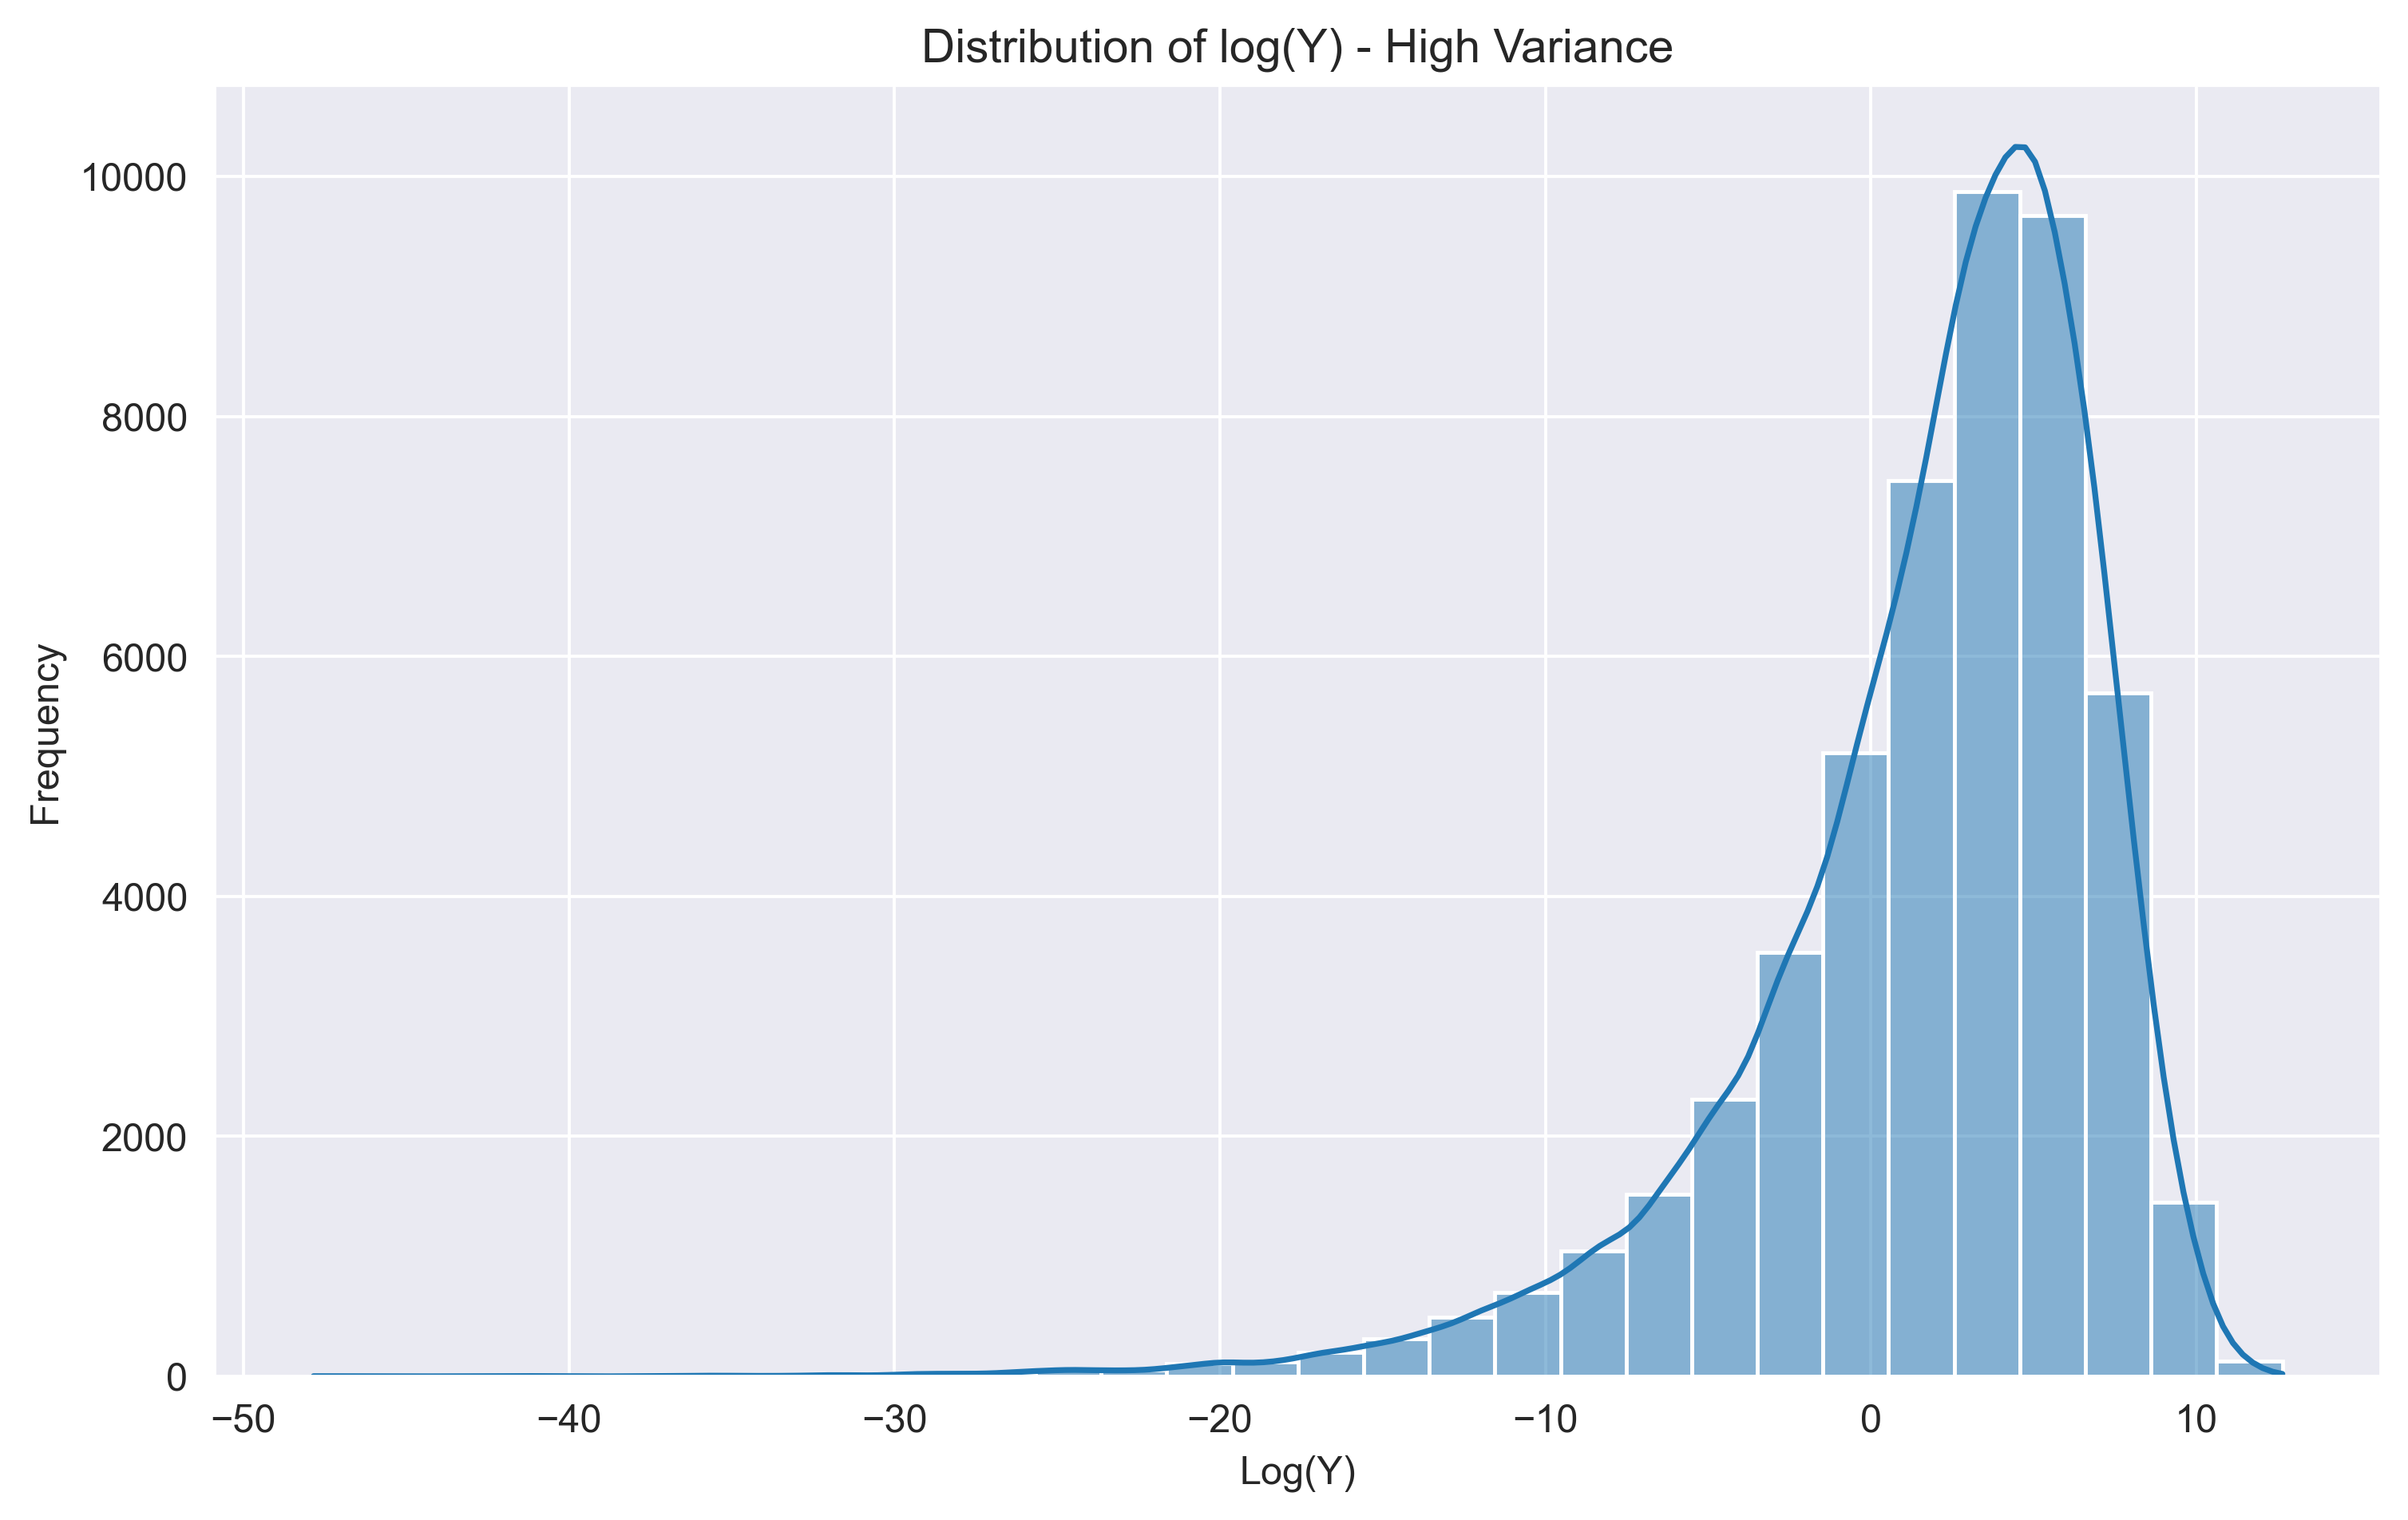

In [13]:
#-------------------------- distribution of log(response) - high variance --------------------------
plt.figure(figsize = (10, 6)) # set the size of the figure
sns.set_style("darkgrid")
sns.histplot(np.log(data_high['Y']), bins = 30, kde = True) # draw the chart
plt.title('Distribution of log(Y) - High Variance')
plt.xlabel('Log(Y)')
plt.ylabel('Frequency')
plt.tick_params(axis = 'x')
plt.tick_params(axis = 'y')
plt.grid(True)
plt.show()

In [ ]:
#-------------------------- export data --------------------------
data_low.to_csv("data/synthetic_low_var.csv", index = False)
data_high.to_csv("data/synthetic_high_var.csv", index = False)